# Impact of $A$ on dipole + clustering map study

The goal of this notebook is to study the impact of A on the injected dipole measurement when a clustering effect is added.

In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
%matplotlib inline
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table
import fitsio

from simulMap import *
from fitMap import *
from utile_fitsFile import *
from mappers import CountMapper

In [2]:
#resolution:
nside = 64
npix = hp.nside2npix(nside)
print("Number of pixels = {}".format(npix))

#sources:
NSource_px_th = int(1e6)
print("Total number of sources in the entire sky : {}".format(NSource_px_th*npix))
print("Theorical number of sources in one pixel : {}".format(NSource_px_th))

Number of pixels = 49152
Total number of sources in the entire sky : 49152000000
Theorical number of sources in one pixel : 1000000


## Importing clustering

In [3]:
DIR = "Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_"
sufix = "zmin0.1"
clFile = DIR + sufix + '.fits'

data = fitsio.FITS(clFile)
data


  file: Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_zmin0.1.fits
  mode: READONLY
  extnum hdutype         hduname[v]
  0      IMAGE_HDU       
  1      BINARY_TBL      MAPS
  2      BINARY_TBL      FIT_NUMPY

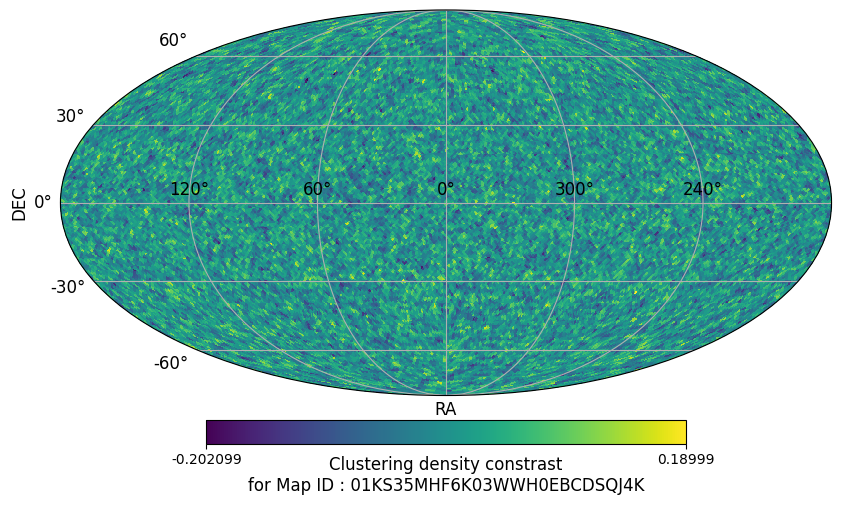

In [4]:
mapID, hpmap = data['MAPS'][0] #first clustering map
hpmap = hp.reorder(hpmap, r2n=True)
clMapper = CountMapper.from_map(hpmap)
clMapper._set_instance_settingsPlot(unit = f"Clustering density constrast\nfor Map ID : {mapID}")
clMapper.plot()

## Study without monopole

In [5]:
DIR = "Fit_Clusters/Clusters_Dipole/Clusters_Dipole_"
sufix = "Param_study_NoMonop"
file = DIR + sufix +".fits"

data2 = fitsio.FITS(file)
data2


  file: Fit_Clusters/Clusters_Dipole/Clusters_Dipole_Param_study_NoMonop.fits
  mode: READONLY
  extnum hdutype         hduname[v]
  0      IMAGE_HDU       
  1      BINARY_TBL      A_STUDY

In [6]:
dfMinuit_data2 = Table(data2['A_STUDY'].read())
mask = dfMinuit_data2["N*_true"] == 1
dfMinuit_filtered = dfMinuit_data2[mask]
dfMinuit_filtered

Map_ID,N*,N*_init,N*_err,N*_fixed,N*_limit_0,N*_limit_1,A,A_init,A_err,A_fixed,A_limit_0,A_limit_1,ra,ra_init,ra_err,ra_fixed,ra_limit_0,ra_limit_1,dec,dec_init,dec_err,dec_fixed,dec_limit_0,dec_limit_1,valid,N*_true,A_true,ra_true,dec_true
str26,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,bool,int64,float64,int64,int64
01KS35MHF6K03WWH0EBCDSQJ4K,1.0,1.0,0.01,True,0.0,inf,3.5180873877307213e-06,1.0,0.03701578553905237,False,0.0,1.0,353.6254440239452,100.0,281.35431145805615,False,0.0,360.0,49.70237446046428,0.0,91.12533330059861,False,-90.0,90.0,True,1,0.001,168,-7
01KS35MHF6K03WWH0EBCDSQJ4K,1.0,1.0,0.01,True,0.0,inf,1.1976489748997618e-06,1.0,0.02623433106236582,False,0.0,1.0,355.7971888667102,100.0,286.8981245506009,False,0.0,360.0,-58.470020915056004,0.0,100.30291045889169,False,-90.0,90.0,True,1,0.0010985411419875584,168,-7
01KS35MHF6K03WWH0EBCDSQJ4K,1.0,1.0,0.01,True,0.0,inf,7.393077763428579e-09,1.0,0.02031598143304724,False,0.0,1.0,357.5743744006001,100.0,292.3459203459573,False,0.0,360.0,-44.317592878082785,0.0,94.23347725550812,False,-90.0,90.0,True,1,0.0012067926406393288,168,-7
01KS35MHF6K03WWH0EBCDSQJ4K,1.0,1.0,0.01,True,0.0,inf,1.627916012467224e-05,1.0,0.08337874382939499,False,0.0,1.0,358.87131437545196,100.0,297.50378994787866,False,0.0,360.0,-89.71482421153605,0.0,150.16007976092885,False,-90.0,90.0,True,1,0.0013257113655901094,168,-7
01KS35MHF6K03WWH0EBCDSQJ4K,1.0,1.0,0.01,True,0.0,inf,8.527557874315518e-07,1.0,0.016076425059284184,False,0.0,1.0,359.6187482395269,100.0,301.8465970510462,False,0.0,360.0,-30.779661237585852,0.0,150.24493065241677,False,-90.0,90.0,True,1,0.0014563484775012444,168,-7
01KS35MHF6K03WWH0EBCDSQJ4K,1.0,1.0,0.01,True,0.0,inf,3.0731268691717355e-05,1.0,0.08895483296880814,False,0.0,1.0,359.9425411779521,100.0,305.3473961608582,False,0.0,360.0,77.8950398835066,0.0,126.085503920964,False,-90.0,90.0,True,1,0.0015998587196060573,168,-7
01KS35MHF6K03WWH0EBCDSQJ4K,1.0,1.0,0.01,True,0.0,inf,0.00013313072047938453,1.0,0.9760558749245158,False,0.0,1.0,359.9935288621875,100.0,257.8051198147675,False,0.0,360.0,88.04194394339653,0.0,163.42593122800935,False,-90.0,90.0,False,1,0.0017575106248547913,168,-7
01KS35MHF6K03WWH0EBCDSQJ4K,1.0,1.0,0.01,True,0.0,inf,0.00017880752993901822,1.0,0.09065774094829485,False,0.0,1.0,359.86621374354525,100.0,289.666853954815,False,0.0,360.0,89.72169958549357,0.0,174.6846963095962,False,-90.0,90.0,True,1,0.0019306977288832496,168,-7
01KS35MHF6K03WWH0EBCDSQJ4K,1.0,1.0,0.01,True,0.0,inf,2.1842404202397788e-05,1.0,0.10677400629082978,False,0.0,1.0,359.6169088241462,100.0,312.51839817570544,False,0.0,360.0,82.31860460244907,0.0,165.53609874369508,False,-90.0,90.0,True,1,0.0021209508879201904,168,-7


Saving Cluster_A_study_diffARaDec_NoMonop in Simul_Figures/Simul_Cluster/Simul_Cluster_ParamStudy/Cluster_A_study_diffARaDec_NoMonop.pdf


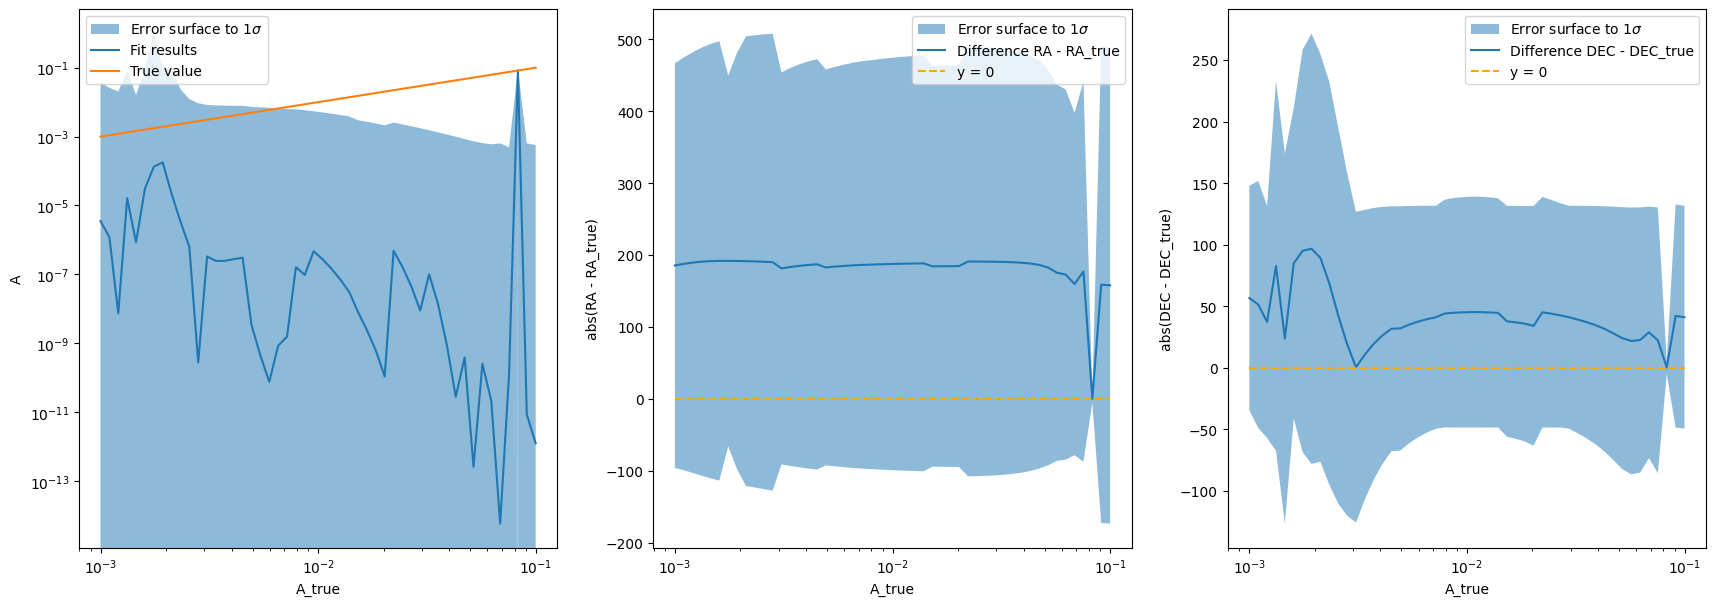

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(3*7,7))
compareFit_val(dfMinuit_filtered, "A", "A", nsigma=1, figax=(fig, ax[0]), yscale="log")
compareFit_diff(dfMinuit_filtered, "A", "ra", ylegend="RA", nsigma=1, figax=(fig, ax[1]))
compareFit_diff(dfMinuit_filtered, "A", "dec", ylegend="DEC", nsigma=1, figax=(fig, ax[2]))

sufix = "Cluster_A_study_diffARaDec_NoMonop"
get_savefig(plt, output_path, sufix)

Saving Cluster_A_study_diffARaDec_NoMonop in Simul_Figures/Simul_Cluster/Simul_Cluster_ParamStudy/Cluster_A_study_diffARaDec_NoMonop.pdf


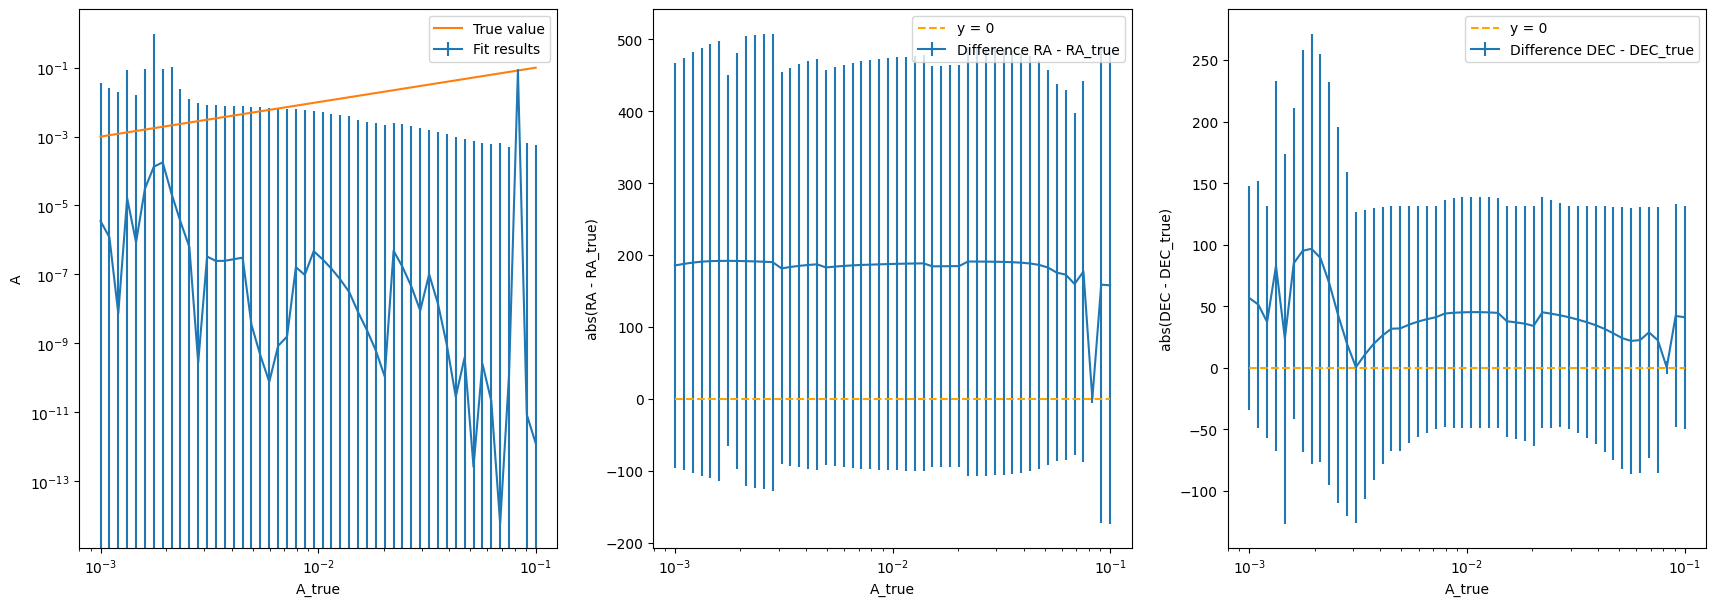

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(3*7,7))
compareFit_val(dfMinuit_filtered, "A", "A", nsigma=1, figax=(fig, ax[0]), yscale="log", surface=False)
compareFit_diff(dfMinuit_filtered, "A", "ra", ylegend="RA", nsigma=1, figax=(fig, ax[1]), surface=False)
compareFit_diff(dfMinuit_filtered, "A", "dec", ylegend="DEC", nsigma=1, figax=(fig, ax[2]), surface=False)

sufix = "Cluster_A_study_diffARaDec_NoMonop"
get_savefig(plt, output_path, sufix)

Saving Cluster_A_study_ratioARaDec_NoMonop in Simul_Figures/Simul_Cluster/Simul_Cluster_ParamStudy/Cluster_A_study_ratioARaDec_NoMonop.pdf


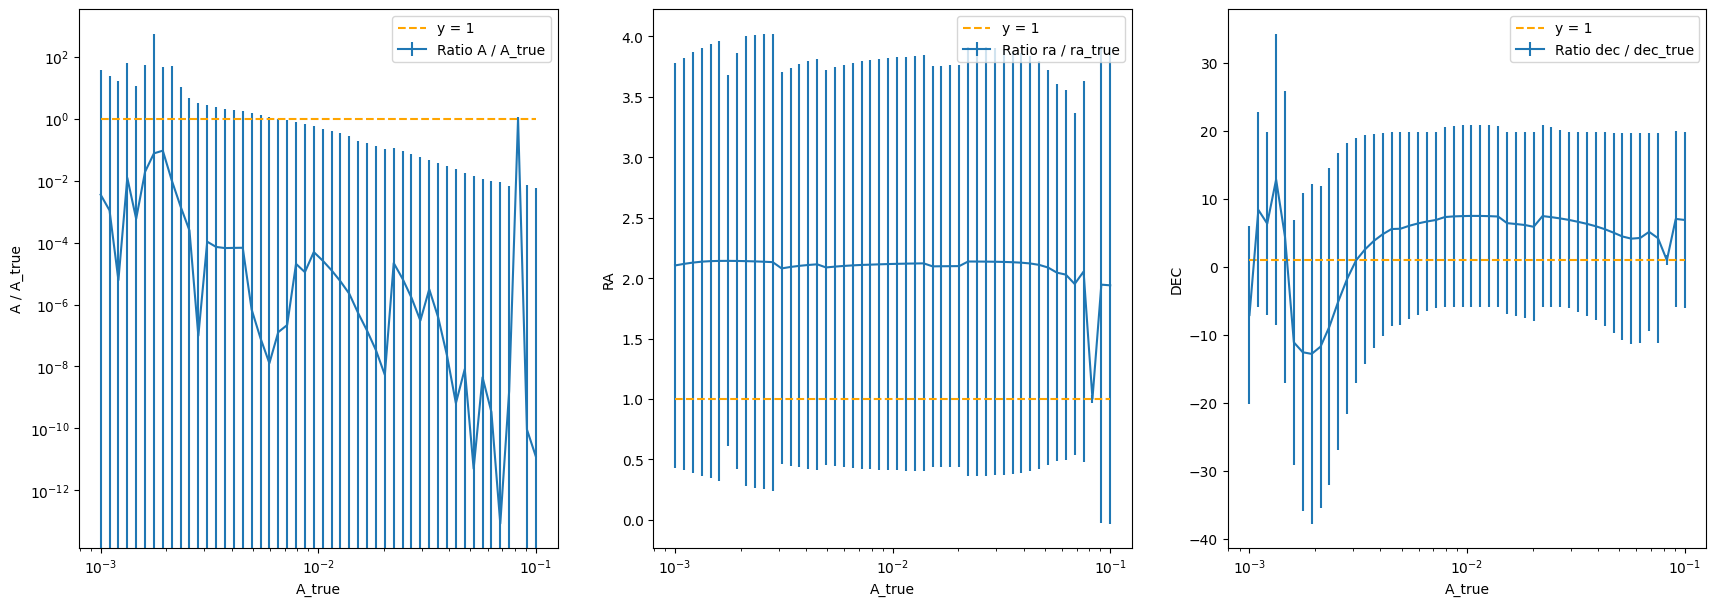

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(3*7,7))
compareFit_ratio(dfMinuit_filtered, "A", "A", nsigma=1, figax=(fig, ax[0]), yscale='log', surface=False)
compareFit_ratio(dfMinuit_filtered, "A", "ra", ylabel="RA", nsigma=5, figax=(fig, ax[1]), surface=False)
compareFit_ratio(dfMinuit_filtered, "A", "dec", ylabel="DEC", nsigma=5, figax=(fig, ax[2]), surface=False)

output_path = "Simul_Figures/Simul_Cluster/Simul_Cluster_ParamStudy/"
sufix = "Cluster_A_study_ratioARaDec_NoMonop"
get_savefig(plt, output_path, sufix)

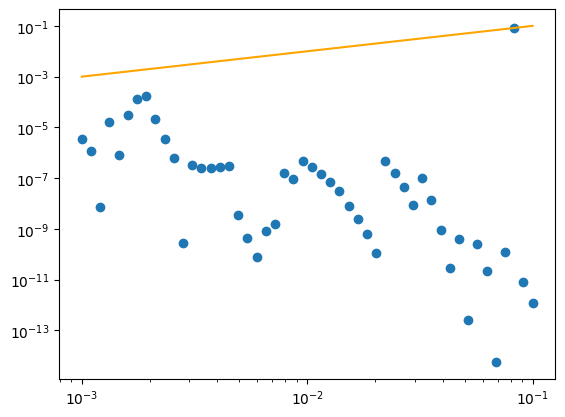

In [17]:
plt.scatter(dfMinuit_filtered["A_true"], dfMinuit_filtered["A"])
plt.plot(dfMinuit_filtered["A_true"], dfMinuit_filtered["A_true"], c='orange')
plt.xscale('log')
plt.yscale('log');

In [18]:
diff = np.abs(dfMinuit_filtered["A"] - dfMinuit_filtered["A_true"])
ymin = diff - 1*dfMinuit_filtered["A_err"]
mask = ymin >=0
dfMinuit_filtered["A_true"][mask]

0.0071968567300115215
0.0079060432109077
0.00868511373751352
0.009540954763499945
0.010481131341546858
0.01151395399326447
0.012648552168552958
0.013894954943731374
0.015264179671752334
0.016768329368110076
0.018420699693267154


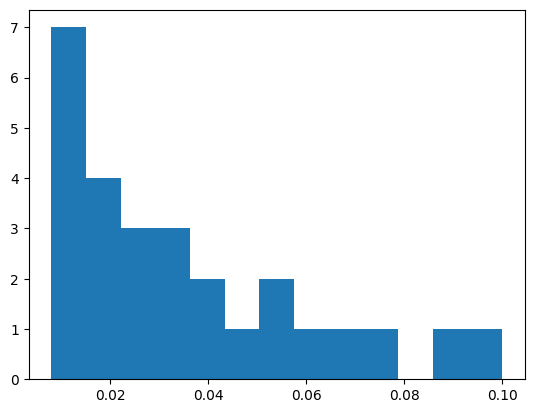

In [19]:
plt.hist(dfMinuit_filtered["A_true"][mask][1:], bins=13);

## Study with monopole

In [20]:
sufix = "Param_study_Monop"
outputfile = DIR + sufix +".fits"

data3 = fitsio.FITS(outputfile)
data3


  file: Fit_Clusters/Clusters_Dipole/Clusters_Dipole_Param_study_Monop.fits
  mode: READONLY
  extnum hdutype         hduname[v]
  0      IMAGE_HDU       
  1      BINARY_TBL      A_STUDY

In [21]:
dfMinuit_data3 = Table(data3['A_STUDY'].read())
mask = dfMinuit_data3["N*_true"] == NSource_px_th
dfMinuit_filtered = dfMinuit_data3[mask]
dfMinuit_filtered

Map_ID,N*,N*_init,N*_err,N*_fixed,N*_limit_0,N*_limit_1,A,A_init,A_err,A_fixed,A_limit_0,A_limit_1,ra,ra_init,ra_err,ra_fixed,ra_limit_0,ra_limit_1,dec,dec_init,dec_err,dec_fixed,dec_limit_0,dec_limit_1,valid,N*_true,A_true,ra_true,dec_true
str26,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,bool,int64,float64,int64,int64
01KS35MHF6K03WWH0EBCDSQJ4K,997572.0008894686,1000000.0,4.505069315317087,False,0.0,inf,0.0015885902111142563,1.0,7.821895434784567e-06,False,0.0,1.0,178.00598398088553,100.0,0.28748981660902473,False,0.0,360.0,11.099285060523343,0.0,0.28221332619434225,False,-90.0,90.0,True,1000000,0.001,168,-7
01KS35MHF6K03WWH0EBCDSQJ4K,997571.9762548702,1000000.0,4.505066590383649,False,0.0,inf,0.0016816599758608898,1.0,7.821830377264648e-06,False,0.0,1.0,177.4113769774895,100.0,0.270664650819171,False,0.0,360.0,10.064098645319802,0.0,0.26659500779704626,False,-90.0,90.0,True,1000000,0.0010985411419875584,168,-7
01KS35MHF6K03WWH0EBCDSQJ4K,997571.9511489944,1000000.0,4.505071128485724,False,0.0,inf,0.0017845020541296113,1.0,7.820957029471042e-06,False,0.0,1.0,176.84367089810232,100.0,0.25426939075863686,False,0.0,360.0,9.046828390490326,0.0,0.2511898540101649,False,-90.0,90.0,True,1000000,0.0012067926406393288,168,-7
01KS35MHF6K03WWH0EBCDSQJ4K,997571.9295503217,1000000.0,4.505065009579994,False,0.0,inf,0.0018983796661076826,1.0,7.820929247258747e-06,False,0.0,1.0,176.2872250613825,100.0,0.23839949420880657,False,0.0,360.0,8.057554271127396,0.0,0.23612534470304025,False,-90.0,90.0,True,1000000,0.0013257113655901094,168,-7
01KS35MHF6K03WWH0EBCDSQJ4K,997571.9245041244,1000000.0,4.5050693152006716,False,0.0,inf,0.0020242810476226577,1.0,7.821507333053042e-06,False,0.0,1.0,175.75644478345657,100.0,0.22309530831954305,False,0.0,360.0,7.09730288995231,0.0,0.22146600724537802,False,-90.0,90.0,True,1000000,0.0014563484775012444,168,-7
01KS35MHF6K03WWH0EBCDSQJ4K,997571.9667887707,1000000.0,4.505071199149825,False,0.0,inf,0.0021631608041506496,1.0,7.820958979765135e-06,False,0.0,1.0,175.24133482912046,100.0,0.20836244529220949,False,0.0,360.0,6.173155616443018,0.0,0.20722483734706465,False,-90.0,90.0,True,1000000,0.0015998587196060573,168,-7
01KS35MHF6K03WWH0EBCDSQJ4K,997571.9203380282,1000000.0,4.505072040250525,False,0.0,inf,0.0023165513342652674,1.0,7.821471189051405e-06,False,0.0,1.0,174.75199078235315,100.0,0.19427354053443935,False,0.0,360.0,5.284324830411686,0.0,0.19351795352021028,False,-90.0,90.0,True,1000000,0.0017575106248547913,168,-7
01KS35MHF6K03WWH0EBCDSQJ4K,997571.9458146329,1000000.0,4.50507204013411,False,0.0,inf,0.0024858533621291935,1.0,7.821370791569844e-06,False,0.0,1.0,174.28427097644635,100.0,0.18081533092279756,False,0.0,360.0,4.432498282833087,0.0,0.18033934880821478,False,-90.0,90.0,True,1000000,0.0019306977288832496,168,-7
01KS35MHF6K03WWH0EBCDSQJ4K,997571.9586060406,1000000.0,4.505069315317087,False,0.0,inf,0.002672375398180748,1.0,7.82141205744099e-06,False,0.0,1.0,173.83876043420304,100.0,0.16802381702190416,False,0.0,360.0,3.6242139568525533,0.0,0.1677481873279023,False,-90.0,90.0,True,1000000,0.0021209508879201904,168,-7


Saving Cluster_A_study_diffARaDec_withN1e6 in Simul_Figures/Simul_Cluster/Simul_Cluster_ParamStudy/Cluster_A_study_diffARaDec_withN1e6.pdf


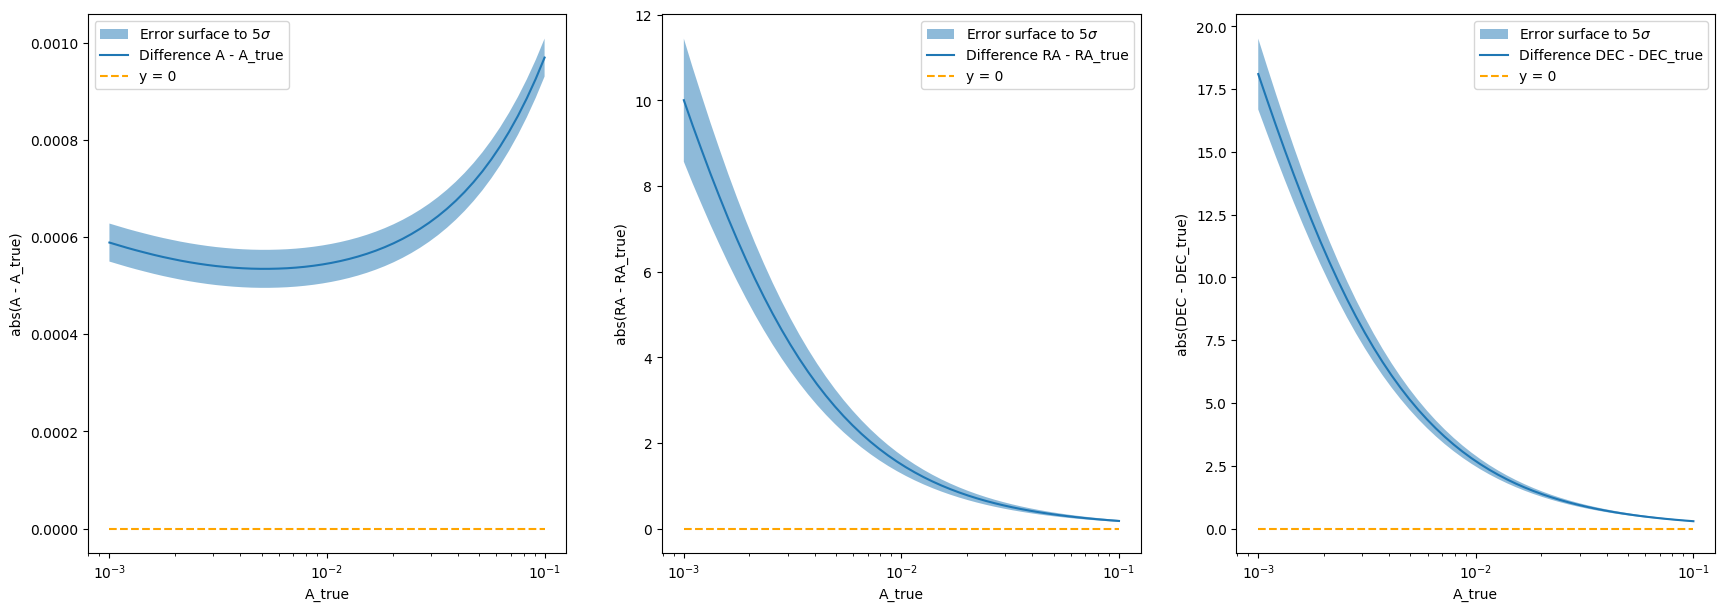

In [22]:
fig, ax = plt.subplots(1, 3, figsize=(3*7,7))
compareFit_diff(dfMinuit_filtered, "A", "A", nsigma=5, figax=(fig, ax[0]))
compareFit_diff(dfMinuit_filtered, "A", "ra", ylegend="RA", nsigma=5, figax=(fig, ax[1]))
compareFit_diff(dfMinuit_filtered, "A", "dec", ylegend="DEC", nsigma=5, figax=(fig, ax[2]))

output_path = "Simul_Figures/Simul_Cluster/Simul_Cluster_ParamStudy/"
sufix = "Cluster_A_study_diffARaDec_withN1e6"
get_savefig(plt, output_path, sufix)

Saving Cluster_A_study_diffARaDec_withN1e6 in Simul_Figures/Simul_Cluster/Simul_Cluster_ParamStudy/Cluster_A_study_diffARaDec_withN1e6.pdf


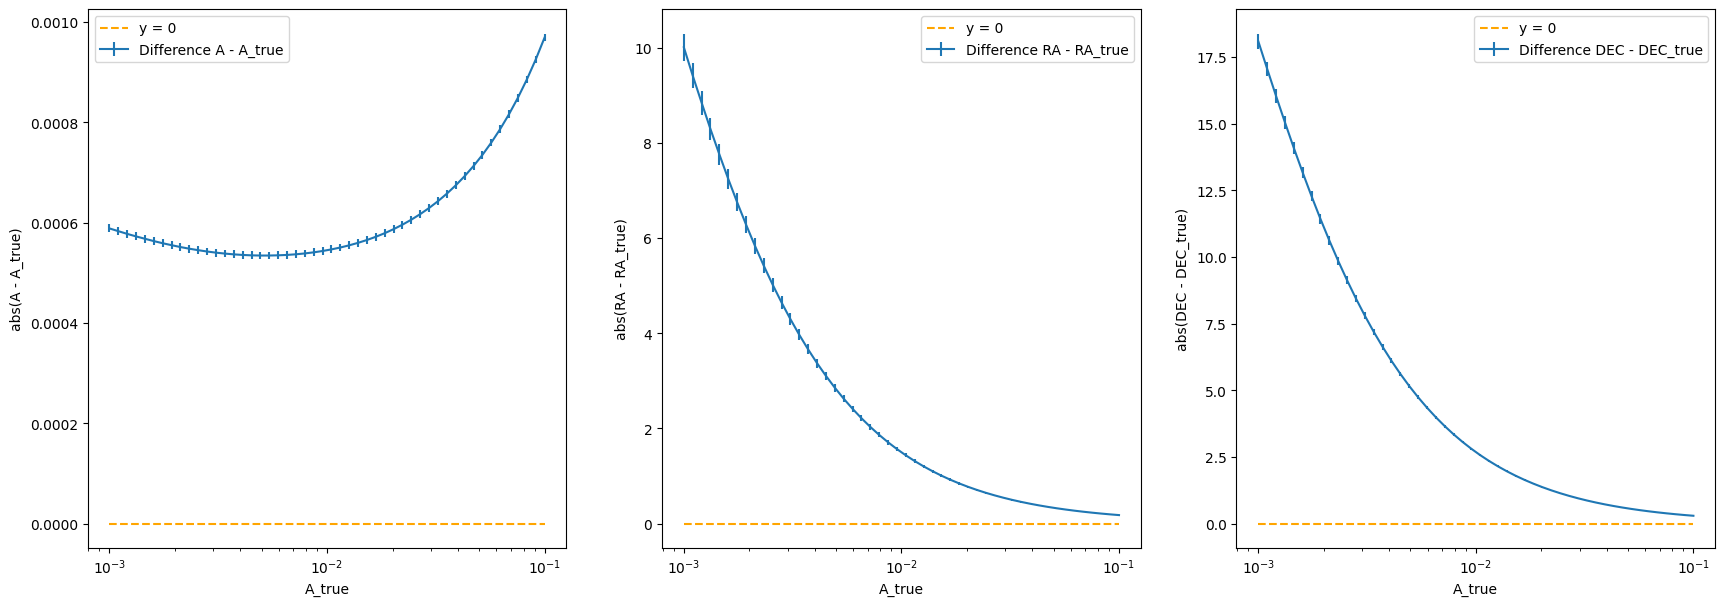

In [23]:
fig, ax = plt.subplots(1, 3, figsize=(3*7,7))
compareFit_diff(dfMinuit_filtered, "A", "A", nsigma=5, figax=(fig, ax[0]), surface=False)
compareFit_diff(dfMinuit_filtered, "A", "ra", ylegend="RA", nsigma=5, figax=(fig, ax[1]), surface=False)
compareFit_diff(dfMinuit_filtered, "A", "dec", ylegend="DEC", nsigma=5, figax=(fig, ax[2]), surface=False)

output_path = "Simul_Figures/Simul_Cluster/Simul_Cluster_ParamStudy/"
sufix = "Cluster_A_study_diffARaDec_withN1e6"
get_savefig(plt, output_path, sufix)

Saving Cluster_A_study_valARaDec_withN1e6 in Simul_Figures/Simul_Cluster/Simul_Cluster_ParamStudy/Cluster_A_study_valARaDec_withN1e6.pdf


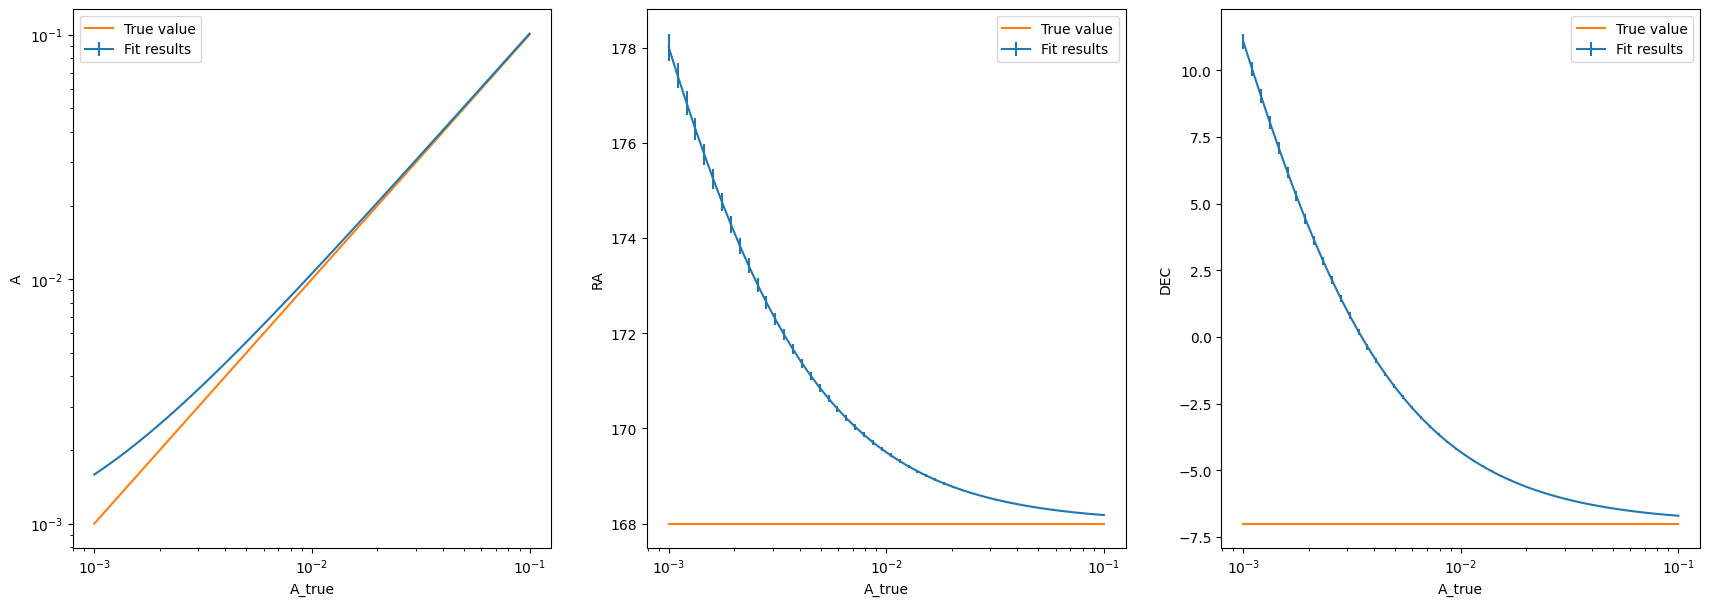

In [24]:
fig, ax = plt.subplots(1, 3, figsize=(3*7,7))
compareFit_val(dfMinuit_filtered, "A", "A", nsigma=1, figax=(fig, ax[0]), yscale='log', surface=False)
compareFit_val(dfMinuit_filtered, "A", "ra", ylabel="RA", nsigma=5, figax=(fig, ax[1]), surface=False)
compareFit_val(dfMinuit_filtered, "A", "dec", ylabel="DEC", nsigma=5, figax=(fig, ax[2]), surface=False)

output_path = "Simul_Figures/Simul_Cluster/Simul_Cluster_ParamStudy/"
sufix = "Cluster_A_study_valARaDec_withN1e6"
get_savefig(plt, output_path, sufix)

Saving Cluster_A_study_ratioARaDec_withN1e6 in Simul_Figures/Simul_Cluster/Simul_Cluster_ParamStudy/Cluster_A_study_ratioARaDec_withN1e6.pdf


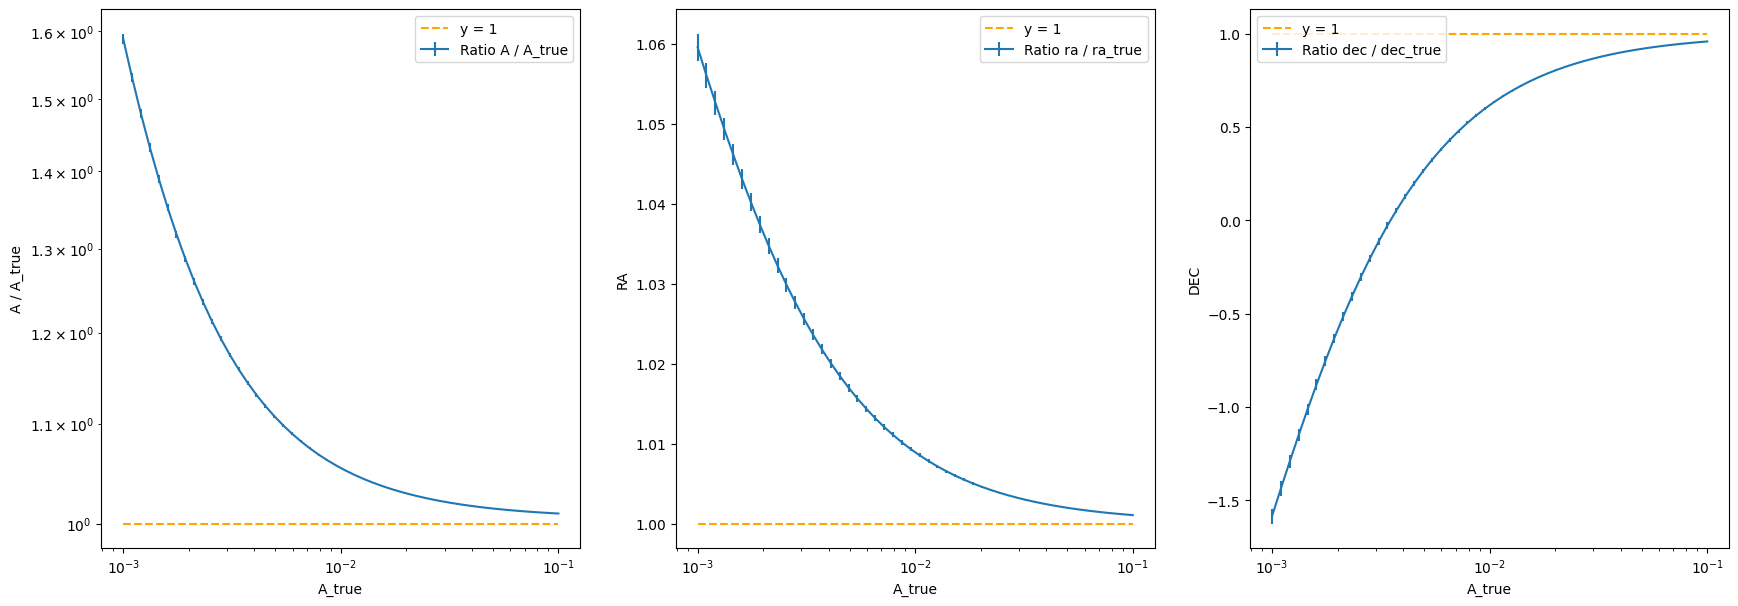

In [25]:
fig, ax = plt.subplots(1, 3, figsize=(3*7,7))
compareFit_ratio(dfMinuit_filtered, "A", "A", nsigma=1, figax=(fig, ax[0]), yscale='log', surface=False)
compareFit_ratio(dfMinuit_filtered, "A", "ra", ylabel="RA", nsigma=5, figax=(fig, ax[1]), surface=False)
compareFit_ratio(dfMinuit_filtered, "A", "dec", ylabel="DEC", nsigma=5, figax=(fig, ax[2]), surface=False)

output_path = "Simul_Figures/Simul_Cluster/Simul_Cluster_ParamStudy/"
sufix = "Cluster_A_study_ratioARaDec_withN1e6"
get_savefig(plt, output_path, sufix)

## Study with Poisson noise

In [26]:
suffix = "Param_study_Monop_poissVar"
outputfile = DIR + suffix +".fits"

data4 = fitsio.FITS(outputfile)
data4


  file: Fit_Clusters/Clusters_Dipole/Clusters_Dipole_Param_study_Monop_poissVar.fits
  mode: READONLY
  extnum hdutype         hduname[v]
  0      IMAGE_HDU       
  1      BINARY_TBL      A_STUDY_MAPS
  2      BINARY_TBL      A_STUDY
  3      BINARY_TBL      A_STUDY_densField

In [27]:
dfMinuit_data4 = Table(data4['A_STUDY'].read())
mask = dfMinuit_data4["N*_true"] == NSource_px_th
dfMinuit_filtered4 = dfMinuit_data4[mask]
dfMinuit_filtered4

Map_ID,N*,N*_init,N*_err,N*_fixed,N*_limit_0,N*_limit_1,A,A_init,A_err,A_fixed,A_limit_0,A_limit_1,ra,ra_init,ra_err,ra_fixed,ra_limit_0,ra_limit_1,dec,dec_init,dec_err,dec_fixed,dec_limit_0,dec_limit_1,valid,N*_true,A_true,ra_true,dec_true,Cluster_ID
str26,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,bool,int64,float64,int64,int64,str26
01KT3QFZZHN10T2CCQSN6K7FTS,997569.0435979697,1.0,4.505061008618213,False,0.0,inf,0.0015916594515308447,1.0,7.820836857628187e-06,False,0.0,1.0,178.13909528315082,100.0,0.28718799972074294,False,0.0,360.0,11.38140507011815,0.0,0.2816294888043984,False,-90.0,90.0,True,1000000,0.001,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
01KT3QG7763SY4ZMZTHATS8R62,997571.4933968903,1.0,4.505066590383649,False,0.0,inf,0.0016897500044231652,1.0,7.821604930977901e-06,False,0.0,1.0,177.43552794218704,100.0,0.2693376576133488,False,0.0,360.0,10.018596254212556,0.0,0.2653272136211733,False,-90.0,90.0,True,1000000,0.0010985411419875584,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
01KT3QGBKCXCCVBVAX36NNF686,997566.1695231035,1.0,4.505055690766312,False,0.0,inf,0.001774246597023835,1.0,7.821870360941066e-06,False,0.0,1.0,176.6179177394753,100.0,0.25574897785706696,False,0.0,360.0,9.020816449532164,0.0,0.25267679044361646,False,-90.0,90.0,True,1000000,0.0012067926406393288,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
01KT3QGHRQQ5ZW5VEPVZCFG2PB,997566.8858942791,1.0,4.505057285656221,False,0.0,inf,0.0018885756202508973,1.0,7.821002519521354e-06,False,0.0,1.0,176.24205788213288,100.0,0.23995128340934002,False,0.0,360.0,8.569364204582676,0.0,0.23734938512335724,False,-90.0,90.0,True,1000000,0.0013257113655901094,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
01KT3QGQ0PT12SAX3GJ4S79HX6,997571.0025295774,1.0,4.505066590383649,False,0.0,inf,0.0020346480479361924,1.0,7.821607786824211e-06,False,0.0,1.0,175.77343433415925,100.0,0.22196604211202953,False,0.0,360.0,7.115375151105414,0.0,0.22033508567901805,False,-90.0,90.0,True,1000000,0.0014563484775012444,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
01KT3QGXGGEK66KP2ZMDPYXEY8,997573.8885798459,1.0,4.50507204013411,False,0.0,inf,0.0021615184718054496,1.0,7.821427915669999e-06,False,0.0,1.0,175.3956477100734,100.0,0.2085950690758409,False,0.0,360.0,6.303557567587396,0.0,0.20740627660473043,False,-90.0,90.0,True,1000000,0.0015998587196060573,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
01KT3QH1WMDJEKT52R139KRZEH,997580.265289763,1.0,4.505088389851153,False,0.0,inf,0.002316843834638432,1.0,7.821520205638852e-06,False,0.0,1.0,174.90375246748872,100.0,0.1941736838593897,False,0.0,360.0,5.038164099273427,0.0,0.1934916486417686,False,-90.0,90.0,True,1000000,0.0017575106248547913,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
01KT3QH6JGJMDVCB2S71H6F7FB,997557.2839152986,1.0,4.505039341398515,False,0.0,inf,0.0024903855821152526,1.0,7.821527680781969e-06,False,0.0,1.0,174.47658771618796,100.0,0.18051790738911677,False,0.0,360.0,4.559157740888317,0.0,0.18001015275142906,False,-90.0,90.0,True,1000000,0.0019306977288832496,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
01KT3QHBV0MJZE115V08RM5P1H,997571.9476382177,1.0,4.50507204013411,False,0.0,inf,0.0026719615300877775,1.0,7.821469856663646e-06,False,0.0,1.0,173.823892740454,100.0,0.1680320890963145,False,0.0,360.0,3.5209609935568533,0.0,0.16777435833592058,False,-90.0,90.0,True,1000000,0.0021209508879201904,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K


Saving Cluster_A_study_ratioARaDec_withN1e6_PoissVar in Simul_Figures/Simul_Cluster/Simul_Cluster_ParamStudy/Cluster_A_study_ratioARaDec_withN1e6_PoissVar.pdf


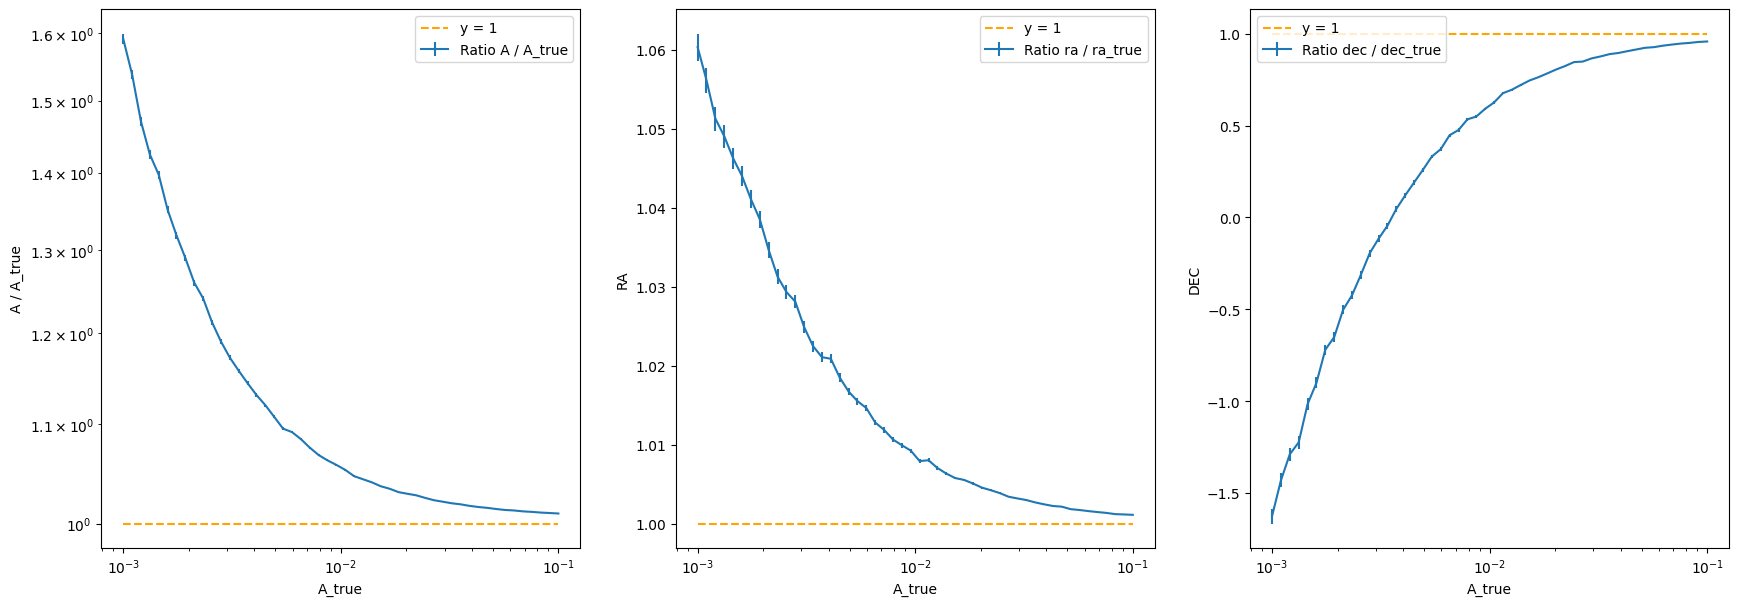

In [28]:
fig, ax = plt.subplots(1, 3, figsize=(3*7,7))
compareFit_ratio(dfMinuit_filtered4, "A", "A", nsigma=1, figax=(fig, ax[0]), yscale='log', surface=False)
compareFit_ratio(dfMinuit_filtered4, "A", "ra", ylabel="RA", nsigma=5, figax=(fig, ax[1]), surface=False)
compareFit_ratio(dfMinuit_filtered4, "A", "dec", ylabel="DEC", nsigma=5, figax=(fig, ax[2]), surface=False)

output_path = "Simul_Figures/Simul_Cluster/Simul_Cluster_ParamStudy/"
sufix = "Cluster_A_study_ratioARaDec_withN1e6_PoissVar"
get_savefig(plt, output_path, sufix)

In [29]:
dfMinuit_data4_dens = Table(data4['A_STUDY_densField'].read())
mask = dfMinuit_data4_dens["N*_fixed"] == True
dfMinuit_filtered4_densMonopFixed = dfMinuit_data4_dens[mask]
dfMinuit_filtered4_densMonopFixed

Map_ID,N*,N*_init,N*_err,N*_fixed,N*_limit_0,N*_limit_1,A,A_init,A_err,A_fixed,A_limit_0,A_limit_1,ra,ra_init,ra_err,ra_fixed,ra_limit_0,ra_limit_1,dec,dec_init,dec_err,dec_fixed,dec_limit_0,dec_limit_1,valid,N*_true,A_true,ra_true,dec_true,Cluster_ID
str26,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,bool,int64,float64,int64,int64,str26
01KT3QFZZHN10T2CCQSN6K7FTS,1.0,1.0,0.01,True,0.0,inf,0.0001504216808546215,1.0,0.08010806823839045,False,0.0,1.0,353.1161794000958,100.0,280.1672724743731,False,0.0,360.0,81.82841394410862,0.0,132.3902544343969,False,-90.0,90.0,True,1,0.001,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
01KT3QG7763SY4ZMZTHATS8R62,1.0,1.0,0.01,True,0.0,inf,1.2532158298013201e-06,1.0,0.02612042270028017,False,0.0,1.0,356.4027199581255,100.0,288.6285829281286,False,0.0,360.0,-58.444890372031956,0.0,100.27610133490221,False,-90.0,90.0,True,1,0.0010985411419875584,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
01KT3QGBKCXCCVBVAX36NNF686,1.0,1.0,0.01,True,0.0,inf,3.2114087572716356e-06,1.0,0.021858647222249325,False,0.0,1.0,358.6919235889206,100.0,296.66983172345624,False,0.0,360.0,-49.793492386828234,0.0,91.19608352366791,False,-90.0,90.0,True,1,0.0012067926406393288,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
01KT3QGHRQQ5ZW5VEPVZCFG2PB,1.0,1.0,0.01,True,0.0,inf,1.4304404873867428e-05,1.0,0.07754283045596058,False,0.0,1.0,359.47891182517134,100.0,300.8617008863273,False,0.0,360.0,-89.14819388752149,0.0,147.43817586153432,False,-90.0,90.0,True,1,0.0013257113655901094,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
01KT3QGQ0PT12SAX3GJ4S79HX6,1.0,1.0,0.01,True,0.0,inf,9.303852487867897e-07,1.0,0.016277430974477772,False,0.0,1.0,359.74222799240505,100.0,302.87906209714333,False,0.0,360.0,-32.9925549299478,0.0,151.4306687994249,False,-90.0,90.0,True,1,0.0014563484775012444,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
01KT3QGXGGEK66KP2ZMDPYXEY8,1.0,1.0,0.01,True,0.0,inf,1.651297227651854e-05,1.0,0.07608879314359274,False,0.0,1.0,359.64081441578287,100.0,302.03517693187075,False,0.0,360.0,75.1886505804542,0.0,121.55435110293463,False,-90.0,90.0,True,1,0.0015998587196060573,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
01KT3QH1WMDJEKT52R139KRZEH,1.0,1.0,0.01,True,0.0,inf,0.0001382620909781867,1.0,0.962980199731796,False,0.0,1.0,359.9046518126606,100.0,325.7979681402305,False,0.0,360.0,88.40088100519667,0.0,159.20660812188578,False,-90.0,90.0,False,1,0.0017575106248547913,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
01KT3QH6JGJMDVCB2S71H6F7FB,1.0,1.0,0.01,True,0.0,inf,0.00020406335054770047,1.0,0.07161022756277319,False,0.0,1.0,359.9974592308843,100.0,244.12969442670655,False,0.0,360.0,89.980066915186,0.0,171.228298524626,False,-90.0,90.0,True,1,0.0019306977288832496,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
01KT3QHBV0MJZE115V08RM5P1H,1.0,1.0,0.01,True,0.0,inf,1.20647782492515e-09,1.0,0.9595751227457838,False,0.0,1.0,359.5417734280474,100.0,321.7817241737981,False,0.0,360.0,79.83053699477996,0.0,174.58935732971392,False,-90.0,90.0,True,1,0.0021209508879201904,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K


Saving Cluster_A_study_ratioARaDec_NoMonop_PoissVar in Simul_Figures/Simul_Cluster/Simul_Cluster_ParamStudy/Cluster_A_study_ratioARaDec_NoMonop_PoissVar.pdf


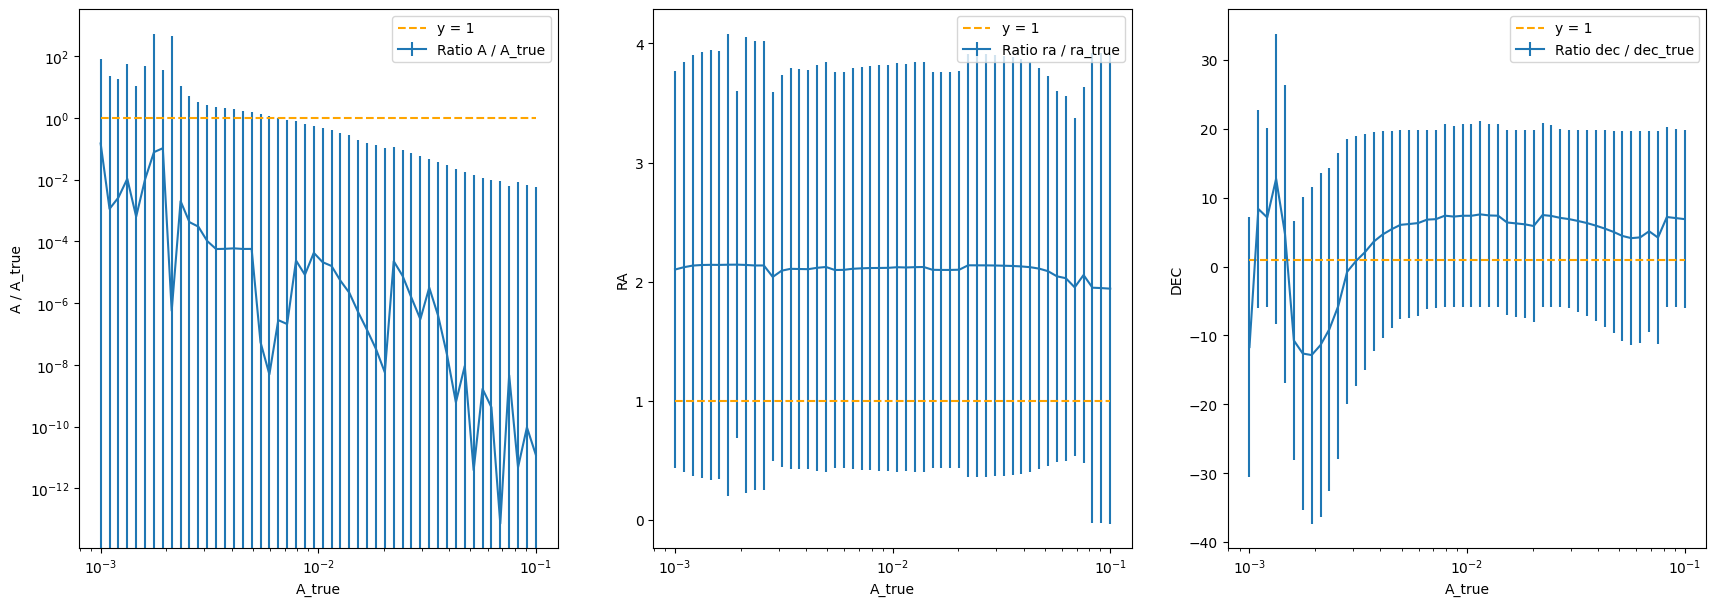

In [35]:
fig, ax = plt.subplots(1, 3, figsize=(3*7,7))
compareFit_ratio(dfMinuit_filtered4_densMonopFixed, "A", "A", nsigma=1, figax=(fig, ax[0]), yscale='log', surface=False)
compareFit_ratio(dfMinuit_filtered4_densMonopFixed, "A", "ra", ylabel="RA", nsigma=5, figax=(fig, ax[1]), surface=False)
compareFit_ratio(dfMinuit_filtered4_densMonopFixed, "A", "dec", ylabel="DEC", nsigma=5, figax=(fig, ax[2]), surface=False)

sufix = "Cluster_A_study_ratioARaDec_NoMonop_PoissVar"
get_savefig(plt, output_path, sufix)

In [31]:
dfMinuit_filtered4_densMonop_notFixed = dfMinuit_data4_dens[~mask]
dfMinuit_filtered4_densMonop_notFixed

Map_ID,N*,N*_init,N*_err,N*_fixed,N*_limit_0,N*_limit_1,A,A_init,A_err,A_fixed,A_limit_0,A_limit_1,ra,ra_init,ra_err,ra_fixed,ra_limit_0,ra_limit_1,dec,dec_init,dec_err,dec_fixed,dec_limit_0,dec_limit_1,valid,N*_true,A_true,ra_true,dec_true,Cluster_ID
str26,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,bool,int64,float64,int64,int64,str26
01KT3QFZZHN10T2CCQSN6K7FTS,0.9977435938260857,1.0,0.004505397555700286,False,0.0,inf,0.00028812848343090904,1.0,0.04526617162890327,False,0.0,1.0,336.7783558672512,100.0,250.82793077252148,False,0.0,360.0,86.04493981354206,0.0,162.1194804959273,False,-90.0,90.0,True,1,0.001,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
01KT3QG7763SY4ZMZTHATS8R62,0.9977433765998709,1.0,0.004505395898273035,False,0.0,inf,0.00022153003885993288,1.0,0.05518884020942001,False,0.0,1.0,344.5262076952035,100.0,263.31207929783733,False,0.0,360.0,84.1861422853536,0.0,164.11280663443728,False,-90.0,90.0,True,1,0.0010985411419875584,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
01KT3QGBKCXCCVBVAX36NNF686,0.9977406708241074,1.0,0.004505398291366147,False,0.0,inf,0.0003258126807833808,1.0,0.04005582933675572,False,0.0,1.0,350.73821609518376,100.0,274.98280436537823,False,0.0,360.0,88.97821177377932,0.0,144.80238336567248,False,-90.0,90.0,True,1,0.0012067926406393288,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
01KT3QGHRQQ5ZW5VEPVZCFG2PB,0.9977066551406008,1.0,0.00450541068903948,False,0.0,inf,7.166339932604762e-06,1.0,0.21097346379648815,False,0.0,1.0,353.08784446592244,100.0,280.1790625242288,False,0.0,360.0,78.8251845530984,0.0,128.2015461704786,False,-90.0,90.0,True,1,0.0013257113655901094,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
01KT3QGQ0PT12SAX3GJ4S79HX6,0.9977414696381484,1.0,0.004505396854567023,False,0.0,inf,2.075821386949081e-06,1.0,0.026757462590006206,False,0.0,1.0,353.98476647224743,100.0,282.22837739718307,False,0.0,360.0,50.24364706532432,0.0,91.65319049120514,False,-90.0,90.0,True,1,0.0014563484775012444,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
01KT3QGXGGEK66KP2ZMDPYXEY8,0.997740894742537,1.0,0.004505398472942401,False,0.0,inf,6.003687992447656e-07,1.0,0.022219020119907163,False,0.0,1.0,353.23468922313776,100.0,280.44294025700316,False,0.0,360.0,45.542096153083925,0.0,93.03536862508821,False,-90.0,90.0,True,1,0.0015998587196060573,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
01KT3QH1WMDJEKT52R139KRZEH,0.9977442555408268,1.0,0.0045053954904296645,False,0.0,inf,2.8767138544116084e-06,1.0,0.030341406443663906,False,0.0,1.0,355.19815804894876,100.0,285.28810007604187,False,0.0,360.0,60.46334319264686,0.0,102.57669283427002,False,-90.0,90.0,True,1,0.0017575106248547913,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
01KT3QH6JGJMDVCB2S71H6F7FB,0.9977260626537086,1.0,0.00450540051478604,False,0.0,inf,4.807873137307528e-07,1.0,0.05517990288548157,False,0.0,1.0,356.6500776980928,100.0,289.3667114037584,False,0.0,360.0,73.55612657636853,0.0,118.52128670357655,False,-90.0,90.0,True,1,0.0019306977288832496,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K
01KT3QHBV0MJZE115V08RM5P1H,0.9977422277761748,1.0,0.004505394897674708,False,0.0,inf,0.0002656872544855039,1.0,0.04536501417917828,False,0.0,1.0,359.2259150254854,100.0,299.3236200814346,False,0.0,360.0,89.97147418742114,0.0,151.928229137825,False,-90.0,90.0,True,1,0.0021209508879201904,168,-7,01KS35MHF6K03WWH0EBCDSQJ4K


Saving Cluster_A_study_ratioARaDec_withN1_PoissVar in Simul_Figures/Simul_Cluster/Simul_Cluster_ParamStudy/Cluster_A_study_ratioARaDec_withN1_PoissVar.pdf


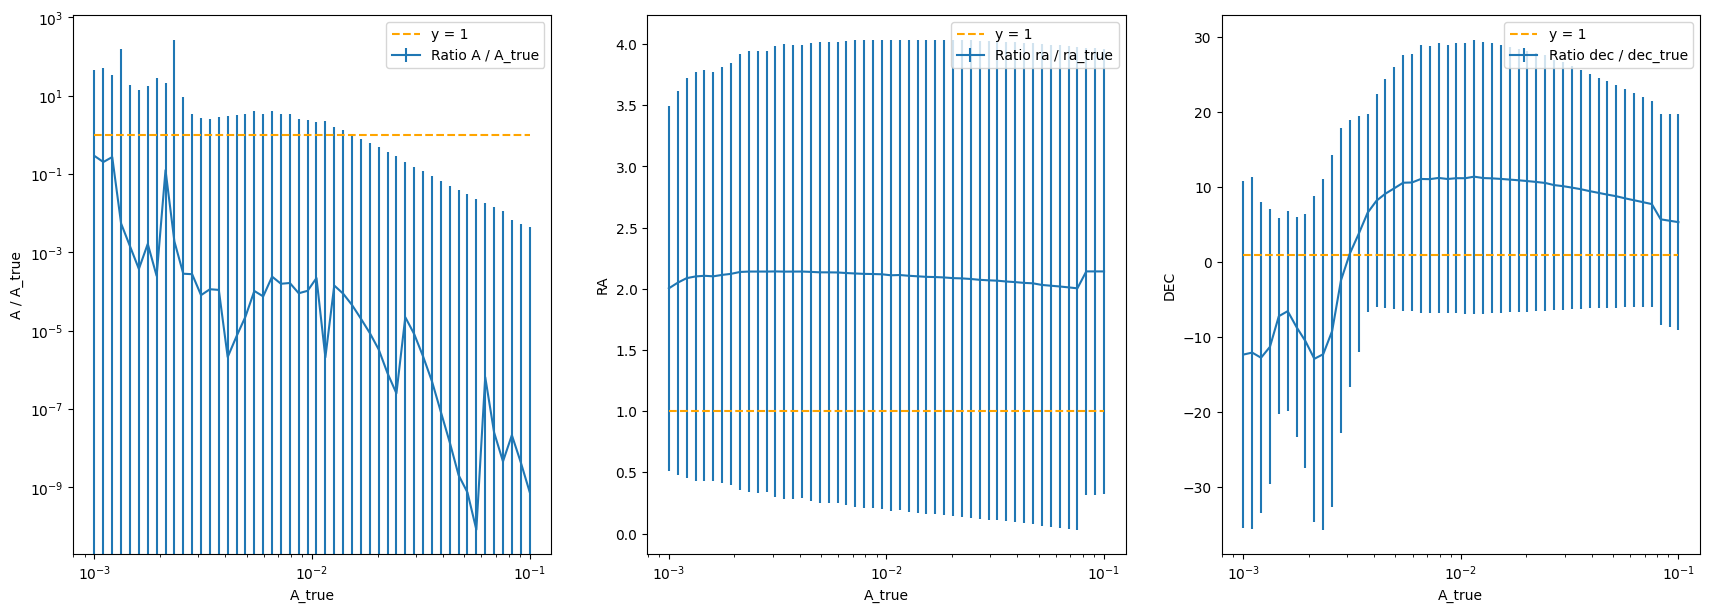

In [34]:
fig, ax = plt.subplots(1, 3, figsize=(3*7,7))
compareFit_ratio(dfMinuit_filtered4_densMonop_notFixed, "A", "A", nsigma=1, figax=(fig, ax[0]), yscale='log', surface=False)
compareFit_ratio(dfMinuit_filtered4_densMonop_notFixed, "A", "ra", ylabel="RA", nsigma=5, figax=(fig, ax[1]), surface=False)
compareFit_ratio(dfMinuit_filtered4_densMonop_notFixed, "A", "dec", ylabel="DEC", nsigma=5, figax=(fig, ax[2]), surface=False)

sufix = "Cluster_A_study_ratioARaDec_withN1_PoissVar"
get_savefig(plt, output_path, sufix)

In [ ]:
def get_term2(log_x, log_x0, alpha, beta, delta):
    x_over_x0 = 10**(log_x - log_x0)
    return (1.0 + x_over_x0**(1.0 / delta)) ** ((beta - alpha) * delta)
    

def smooth_broken_power_law_log(log_x, log_A, log_x0, alpha, beta, delta=0.5):
    """
    Modèle de Smooth Broken Power-Law adapté aux données en échelle log.
    
    Paramètres :
    ------------
    log_x  : array-like, le log10 de la variable indépendante (log10(A_true))
    log_A  : float, normalisation (en log10)
    log_x0 : float, position du coude (en log10(A_true)) -> C'est ce que vous cherchez !
    alpha  : float, pente asymptotique avant le coude (x << x0)
    beta   : float, pente asymptotique après le coude (x >> x0)
    delta  : float, paramètre de lissage (smoothness). 
             Plus delta est petit, plus la transition est douce.
    """
    x_over_x0 = 10**(log_x - log_x0)
    
    # Formule mathématique de la Smooth Broken Power-Law
    term1 = x_over_x0 ** alpha
    #term2 = get_term2(log_x, log_x0, alpha, beta, delta)
    term2 = (1.0 + x_over_x0**(1.0 / delta)) ** ((beta - alpha) * delta)
    
    log_y = log_A + np.log10(term1 * term2)
    return log_y


par = "dec"
diff = np.abs(dfMinuit_filtered[par] - dfMinuit_filtered[f"{par}_true"])
init = (-1, -1.2, -0.8, 0, -0.3)
x_fit = np.log10(dfMinuit_filtered["A_true"])
y_fit = np.log10(diff)
y_err = np.log10(dfMinuit_filtered[f"{par}_err"])
par_name = ('log_A', 'log_x0', 'alpha', 'beta', 'delta')
bounds = ([-np.inf, -2, -np.inf, -np.inf, -np.inf], [np.inf, -1, np.inf, np.inf, np.inf])
bounds = list(zip(bounds[0], bounds[1]))
bounds = None

m = fit_minuit(x_fit, y_fit, y_err, smooth_broken_power_law_log, init, par_name, bounds=bounds)

# y_plot = smooth_broken_power_law_log(x_fit, *m.values)
# plt.scatter(10**x_fit, 10**y_fit)
# plt.plot(10**x_fit, 10**y_plot, c='r')
# plt.xscale('log');


m

In [ ]:
10**m.values[1]

In [ ]:
y_plot = smooth_broken_power_law_log(x_fit, *m.values)
plt.scatter(10**x_fit, 10**y_fit)
plt.plot(10**x_fit, 10**y_plot, c='r')
plt.xscale('log')
#plt.plot(10**x_fit, 10**np.power((x_fit - m.values[1]), m.values[2]));
#plt.plot(10**x_fit, get_term2(x_fit, *m.values[1:]));

In [ ]:
def plot_fit_err(x_fit, y_fit, y_err, values, model, nsigma=, **kwargs):
    '''Plot on a same figure data and its fit, and return the corresponding fig, ax variables.
    
    Parameters:
    - x_fit, y_fit: original data used to compute the fit.
    - values: tuple containing the parameter values obtainds by the fit.
    - model: fitted function. The fit plot is obtained by: ax.plot(bins, model(x_fit, *values))

    Spetial keys for **kwargs:
     - title, xlabel, ylabel: allow to custom the figure.
     - figax: allow to use existing fig, ax variables, rather creating new ones; have to be tuple (fig, ax).
    '''
    if "figax" in kwargs.keys(): fig, ax = kwargs["figax"] #figax have to be tuple (fig, ax).
    else: fig, ax = plt.subplots()
    ax.scatter(x_fit, y_fit, label="data")
    ax.plot(x_fit, model(x_fit, *values), c="r", label="fit")
    y_inf = y_fit - y_err
    y_sup = y_fit + y_err
    ax.fill_between(x_fit, y_inf, y_sup, alpha=0.5, label=f"Error surface to {nsigma}$\sigma$")
    ax.legend()
    if "title" in kwargs.keys(): ax.set_title(kwargs["title"])
    if "xlabel" in kwargs.keys(): ax.set_xlabel(kwargs["xlabel"])
    if "ylabel" in kwargs.keys(): ax.set_xlabel(kwargs["ylabel"])

    #Saving figure:
    output_path = kwargs.get("output_path", False)
    if output_path:
        ext = kwargs.get('format', 'pdf')
        get_savefig(fig=fig, output_path=output_path, sufix="Fit", format=ext)
    return fig, ax

plot_fit_err(x_fit, y_fit, y_err, m.values, smooth_broken_power_law_log);

In [ ]:
def smooth_broken_power_law(x, A, x0, alpha, beta, delta=0.5):
    log_x, log_A, log_x0 = np.log10(x), np.log10(A), np.log10(x0)
    log_y = smooth_broken_power_law_log(log_x, log_A, log_x0, alpha, beta, delta)
    return 10**log_y


par = "ra"
diff = np.abs(dfMinuit_filtered[par] - dfMinuit_filtered[f"{par}_true"])
init = (1e-10, 6e-2, -0.8, 0, -0.3)
x_fit = dfMinuit_filtered["A_true"].copy()
y_fit = diff
y_err = dfMinuit_filtered[f"{par}_err"].copy()
par_name = ('A', 'x0', 'alpha', 'beta', 'delta')
bounds=([0, 0, -90], [1, 360, 90])

m = fit_minuit(x_fit, y_fit, y_err, smooth_broken_power_law, init, par_name)
m

In [ ]:
1e-10

In [ ]:
from lumMag_sampling import proba_schechter_lumRatio

def shchect_log(log_x, log_A, log_x0, alpha, phi_star):
    return proba_schechter_lumRatio(log_x/log_x, alpha, phi_star)


par = "dec"
diff = np.abs(dfMinuit_filtered[par] - dfMinuit_filtered[f"{par}_true"])
init = (-1, -1.2, -1, 0)
x_fit = np.log10(dfMinuit_filtered["A_true"])
y_fit = np.log10(diff)
y_err = np.log10(dfMinuit_filtered[f"{par}_err"])
par_name = ('log_A', 'log_x0', 'alpha', 'phi_star')
bounds = ([-np.inf, -2, -np.inf, -np.inf], [np.inf, -1, np.inf, np.inf])
bounds = list(zip(bounds[0], bounds[1]))
bounds = None

m = fit_minuit(x_fit, y_fit, y_err, shchect_log, init, par_name, bounds=bounds)

# y_plot = smooth_broken_power_law_log(x_fit, *m.values)
# plt.scatter(10**x_fit, 10**y_fit)
# plt.plot(10**x_fit, 10**y_plot, c='r')
# plt.xscale('log');


m